In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np

In [2]:
tesla_df = pd.read_csv("PM_tesla_PW_may22-sept22.csv")
tesla_df.head()

,timestamp,status,operation_mode,grid_status,grid_power,battery_soc,battery_power,backup_reserve_percent,battery_voltage,battery_amperage,load_power,load_voltage,load_amperage,solar_power,solar_voltage,solar_amperage,frequency,nominal_full_pack_energy
0,2022-04-30 21:00:00 +0000,ok,autonomous,SystemGridConnected,-1.167,82.964,1070.833,5.0,230.433,-24.725,1055.396,398.235,2.650,-10.000,204.541,0.705,49.989,27969.500
1,2022-04-30 21:01:00 +0000,ok,autonomous,SystemGridConnected,2.727,82.895,1062.727,5.0,231.755,-24.618,1051.205,400.627,2.624,-10.091,205.767,0.707,49.990,27969.909
2,2022-04-30 21:02:00 +0000,ok,autonomous,SystemGridConnected,-30.833,82.830,1141.667,5.0,232.425,-25.175,1113.063,401.601,2.771,-10.000,206.270,0.712,50.026,27969.833
3,2022-04-30 21:03:00 +0000,ok,autonomous,SystemGridConnected,4.818,82.763,1217.273,5.0,232.382,-28.227,1208.523,401.530,3.010,-10.091,206.236,0.711,50.047,27969.273
4,2022-04-30 21:04:00 +0000,ok,autonomous,SystemGridConnected,6.833,82.685,1224.167,5.0,232.658,-28.150,1220.854,402.163,3.036,-10.000,206.552,0.716,49.984,27969.500


In [3]:
grid_power = tesla_df[['timestamp', 'grid_power']]

In [4]:
grid_power['grid_power'].clip(lower=None, upper=0, inplace=True)

/tmp/ipykernel_22118/4076364877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'].clip(lower=None, upper=0, inplace=True)


In [5]:
grid_power['grid_power'] = -grid_power['grid_power']

/tmp/ipykernel_22118/4246420778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power['grid_power'] = -grid_power['grid_power']


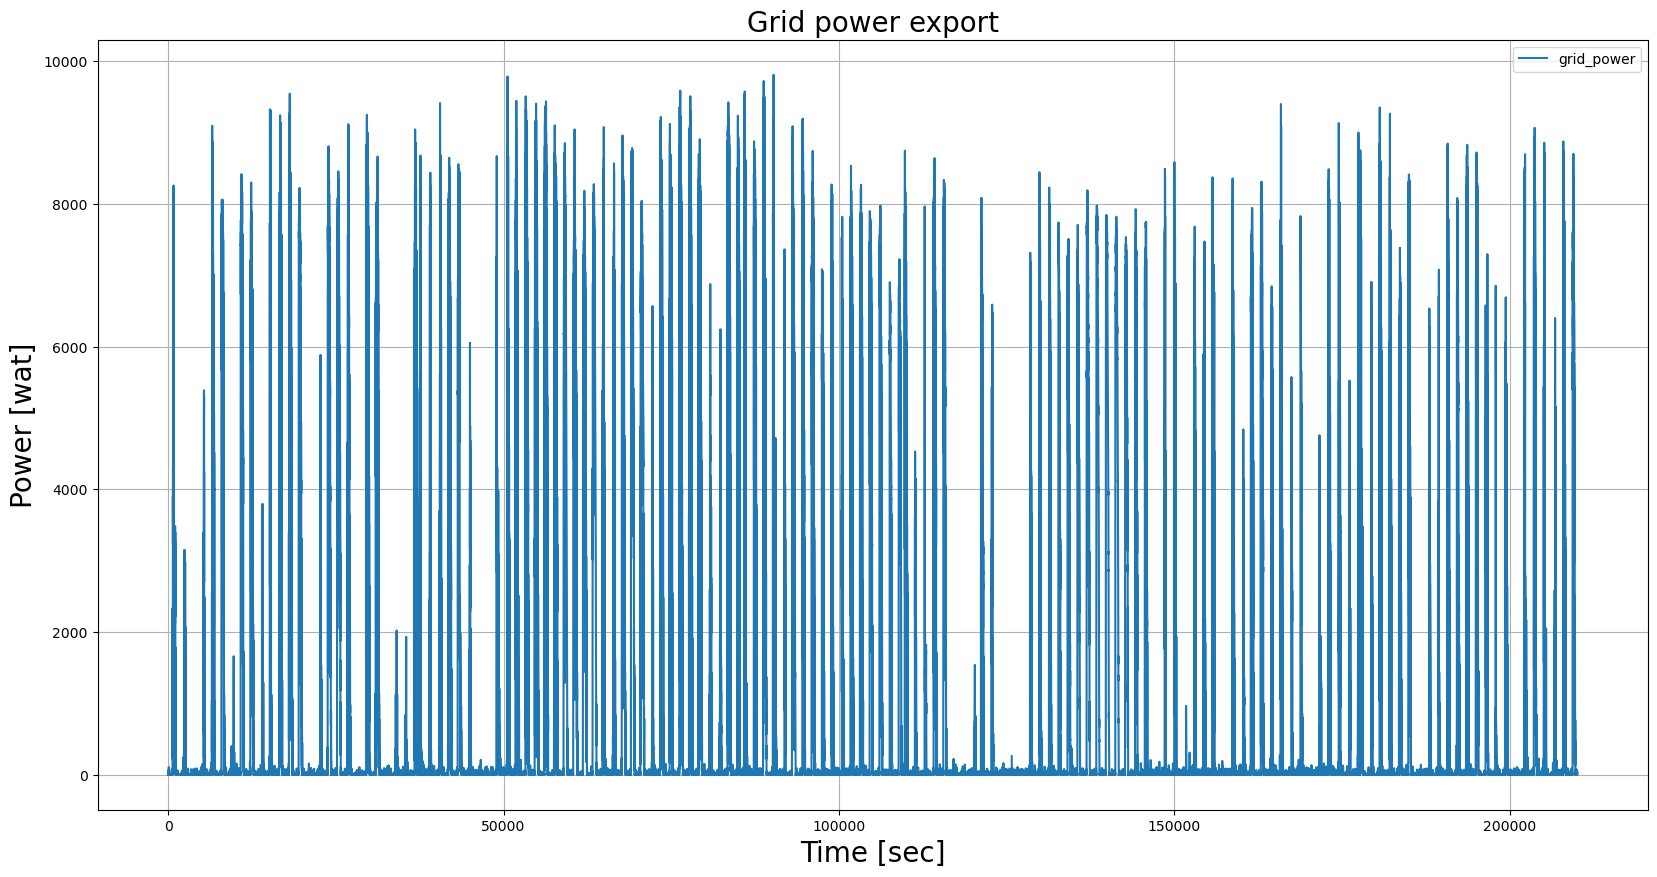

In [6]:
fig, ax = plt.subplots(figsize=(20, 10)) # (13, 6)
ax.set_title(f"Grid power export", fontsize=20)
plt.plot(grid_power['grid_power'], label='grid_power')
ax.set_xlabel(f'Time [sec]', fontsize=20)
ax.set_ylabel(f'Power [wat]', fontsize=20)
plt.legend()
plt.grid(visible=True)
plt.show()

In [7]:
grid_power["timestamp"] = pd.to_datetime(grid_power["timestamp"])

/tmp/ipykernel_22118/3169886386.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grid_power["timestamp"] = pd.to_datetime(grid_power["timestamp"])


In [25]:
timestamp_start = pd.Timestamp(2022, 6, 2, 7).tz_localize('UTC')
timestamp_end = pd.Timestamp(2022, 6, 2, 19).tz_localize('UTC')

def get_data_slice(timestamp_start: pd.Timestamp, timedelta: pd.Timedelta):
    timestamp_end = timestamp_start + timedelta
    day = grid_power.loc[(grid_power["timestamp"] > timestamp_start) & (grid_power["timestamp"] < timestamp_end)]
    if day.isna().values.any():
        return None
    return day



In [26]:
one_day_grid_power_df = get_data_slice(pd.Timestamp(2022, 6, 2, 7).tz_localize('UTC'), pd.Timedelta('12:00:00'))

In [27]:
one_day_grid_power_array = one_day_grid_power_df['grid_power'].to_numpy()

In [28]:
len(one_day_grid_power_array)

720

In [30]:
one_day_grid_power_df

,timestamp,grid_power
41633,2022-06-02 07:01:00+00:00,6.636
41634,2022-06-02 07:02:00+00:00,3.167
41635,2022-06-02 07:03:00+00:00,-0.000
41636,2022-06-02 07:04:00+00:00,-0.000
41637,2022-06-02 07:05:00+00:00,-0.000
...,...,...
42348,2022-06-02 18:55:00+00:00,-0.000
42349,2022-06-02 18:56:00+00:00,-0.000
42350,2022-06-02 18:57:00+00:00,-0.000
42351,2022-06-02 18:58:00+00:00,-0.000


In [43]:
def change_granularity_1_to_15_minutes(array: np.ndarray):
    N = len(array) // 15
    array_new = []
    for i in range(N):
        array_new.append(np.mean(array[i*15 : (i+1)*15]))
    return np.array(array_new)

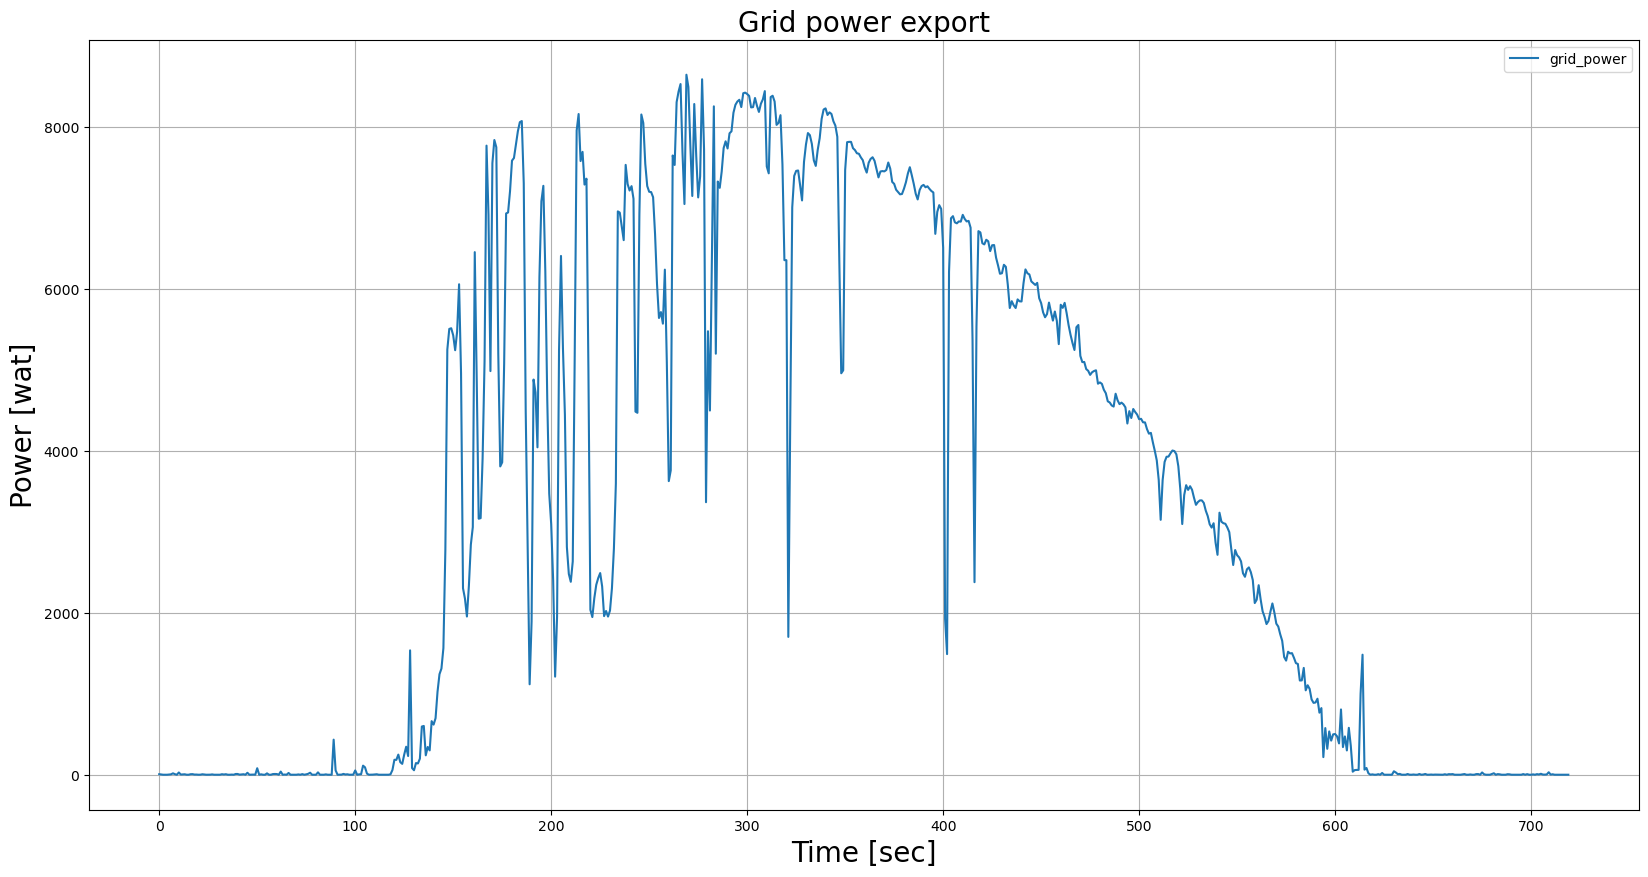

In [44]:
fig, ax = plt.subplots(figsize=(20, 10)) # (13, 6)
ax.set_title(f"Grid power export", fontsize=20)
plt.plot(one_day_grid_power_array, label='grid_power')
ax.set_xlabel(f'Time [sec]', fontsize=20)
ax.set_ylabel(f'Power [wat]', fontsize=20)
plt.legend()
plt.grid(visible=True)
plt.show()

In [47]:
one_day_grid_power_array_15_minute = change_granularity_1_to_15_minutes(one_day_grid_power_array)

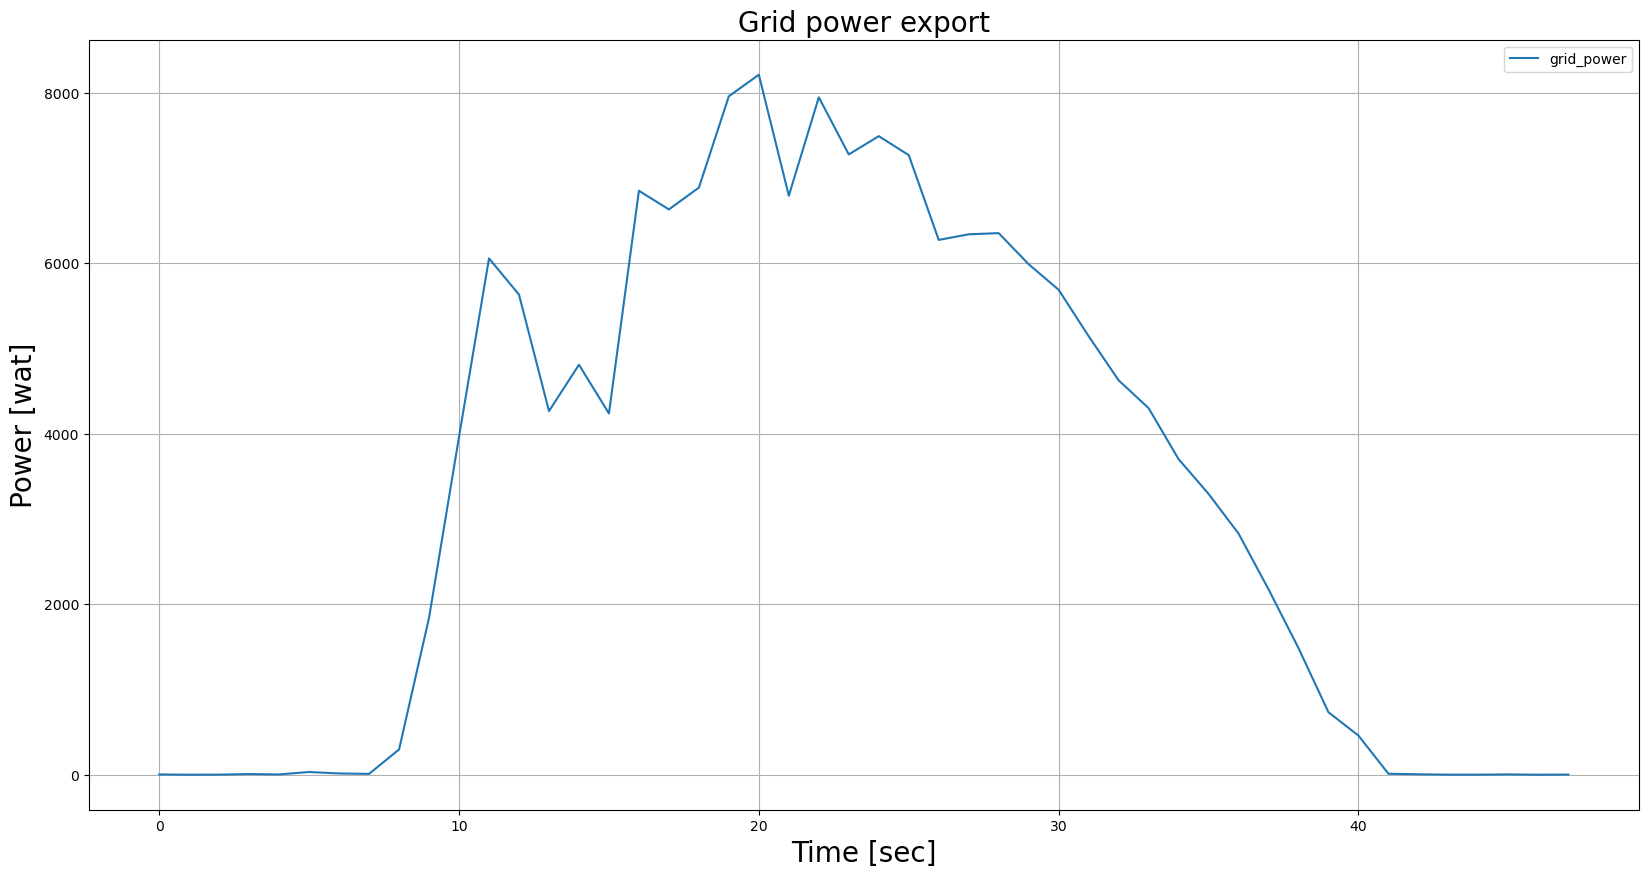

In [48]:
fig, ax = plt.subplots(figsize=(20, 10)) # (13, 6)
ax.set_title(f"Grid power export", fontsize=20)
plt.plot(one_day_grid_power_array_15_minute, label='grid_power')
ax.set_xlabel(f'Time [sec]', fontsize=20)
ax.set_ylabel(f'Power [wat]', fontsize=20)
plt.legend()
plt.grid(visible=True)
plt.show()

In [36]:
one_day_grid_power_array_15_minute